In [1]:
import pandas as pd

data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\ktra3\Data\Stock_Prices_VN-30_Index-Vietnam_10years_to_2023\ACB.csv"

df = pd.read_csv(data_path)
df

,Symbol,Value,TradingDate,Time,Open,High,Low,Close,Volume
0,ACB,4.397575e+10,02/01/2013,NaN,16300,17400,16300,17300,2578600
1,ACB,3.379012e+10,03/01/2013,NaN,17500,17800,16700,17000,1967200
2,ACB,1.989316e+10,04/01/2013,NaN,16900,17200,16700,17200,1170100
3,ACB,2.333590e+10,07/01/2013,NaN,17000,17500,17000,17200,1355700
4,ACB,3.749339e+10,08/01/2013,NaN,17100,17500,16900,17300,2180000
...,...,...,...,...,...,...,...,...,...
2701,ACB,2.615765e+11,26/06/2023,NaN,22200,22500,22000,22250,11784600
2702,ACB,1.253626e+11,27/06/2023,NaN,22550,22550,22200,22200,5619900
2703,ACB,1.825951e+11,28/06/2023,NaN,22200,22400,22100,22300,8230200
2704,ACB,1.804229e+11,29/06/2023,NaN,22300,22400,21900,21900,8151200


***Cell 1 – Import & cấu hình chung***

In [2]:
# B22DCCN476 - Đỗ Ngọc Lâm
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (8, 5)
tf.get_logger().setLevel('ERROR')


***Cell 2 – Đọc dữ liệu & tiền xử lý***

In [3]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cập nhật đường dẫn CSV tương ứng máy bạn:
data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\ktra3\Data\Stock_Prices_VN-30_Index-Vietnam\FPT.csv"

df = pd.read_csv(data_path)

# Chuẩn hoá tên cột: bỏ <> và khoảng trắng
df.columns = [c.strip().replace("<", "").replace(">", "") for c in df.columns]

# Kỳ vọng các cột chính
required_cols = ['Ticker','DTYYYYMMDD','Open','High','Low','Close','Volume']
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Thiếu cột: {missing}"

# Xử lý thời gian & sắp xếp tăng dần
df['Date'] = pd.to_datetime(df['DTYYYYMMDD'], format="%Y%m%d")
df = df.sort_values('Date').reset_index(drop=True)

# Nhãn: ngày mai tăng (1) hay không tăng (0)
df['Close_next'] = df['Close'].shift(-1)
df['UpNext'] = (df['Close_next'] > df['Close']).astype(int)

# Đặc trưng cơ bản + rolling
df['Return_1d']  = df['Close'].pct_change()
df['HL_Spread']  = (df['High'] - df['Low']) / df['Close'].replace(0, np.nan)
df['OC_Spread']  = (df['Close'] - df['Open']) / df['Open'].replace(0, np.nan)
df['Vol_Change'] = df['Volume'].pct_change()

for w in [3, 5, 10]:
    df[f'RollMean_{w}'] = df['Close'].rolling(w).mean()
    df[f'RollStd_{w}']  = df['Close'].rolling(w).std()
    df[f'Return_{w}d']  = df['Close'].pct_change(w)

# Bỏ NA sinh ra bởi shift/rolling
df = df.dropna().reset_index(drop=True)

# Tập đặc trưng
feature_cols = ['Open','High','Low','Close','Volume','Return_1d','HL_Spread','OC_Spread','Vol_Change',
                'RollMean_3','RollStd_3','Return_3d','RollMean_5','RollStd_5','Return_5d',
                'RollMean_10','RollStd_10','Return_10d']
X = df[feature_cols].values
y = df['UpNext'].values
dates = df['Date'].values

print(df.head(3))
print(f"Tổng số bản ghi sau tiền xử lý: {len(df)}")


  Ticker  DTYYYYMMDD     Open     High      Low    Close  Volume       Date  Close_next  UpNext  Return_1d  HL_Spread  OC_Spread  Vol_Change  RollMean_3  RollStd_3  Return_3d  \
0    FPT    20061228  23.3212  23.3212  22.8353  23.3212  144840 2006-12-28     22.3494       0   0.000000   0.020835   0.000000   -0.649493   22.981100   0.589070   0.095890   
1    FPT    20061229  22.5924  22.5924  22.3495  22.3494   69760 2006-12-29     21.3777       0  -0.041670   0.010868  -0.010756   -0.518365   22.997267   0.561069   0.002175   
2    FPT    20070102  21.3777  21.8635  21.3777  21.3777   81170 2007-01-02     21.8636       1  -0.043478   0.022725   0.000000    0.163561   22.349433   0.971750  -0.083336   

   RollMean_5  RollStd_5  Return_5d  RollMean_10  RollStd_10  Return_10d  
0    22.52438   0.848933  -0.010308     22.84989    1.073790    0.142860  
1    22.51466   0.851017  -0.002170     22.94220    0.972734    0.043083  
2    22.53408   0.816212   0.004563     22.83045    1.087243  

***Cell 3 – Chia tập Train/Val/Test theo thời gian + Scale***

In [4]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Chia theo thời gian 70/15/15
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]

dates_train = dates[:n_train]
dates_val   = dates[n_train:n_train+n_val]
dates_test  = dates[n_train+n_val:]

# Chuẩn hoá theo train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Shapes:", X_train_sc.shape, X_val_sc.shape, X_test_sc.shape)


Shapes: (2524, 18) (540, 18) (542, 18)


***Cell 4 – Vẽ ma trận tương quan (Correlation Matrix) trước khi xây dựng mô hình***

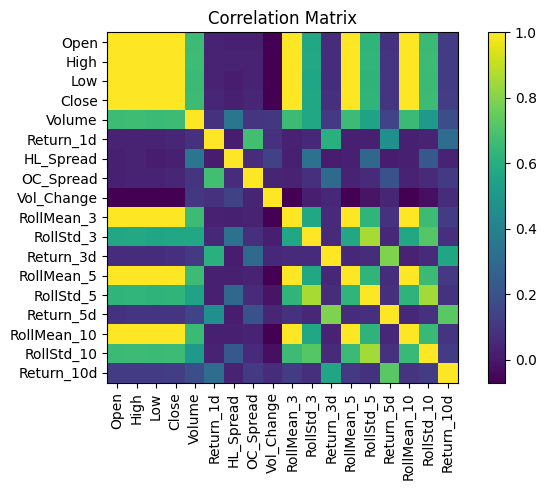

In [5]:
# B22DCCN476 - Đỗ Ngọc Lâm
corr = pd.DataFrame(X, columns=feature_cols).corr()

plt.figure()
im = plt.imshow(corr.values, interpolation='nearest')
plt.title("Correlation Matrix")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


***Cell 5 – Tạo chuỗi (window) cho LSTM, không rò rỉ tương lai***

In [6]:
# B22DCCN476 - Đỗ Ngọc Lâm
WINDOW = 60  # số ngày nhìn lại

def make_sequences(X_2d, y_1d, window):
    X_list, y_list = [], []
    for i in range(window, len(X_2d)):
        X_list.append(X_2d[i-window:i, :])
        y_list.append(y_1d[i])
    return np.array(X_list), np.array(y_list)

# Tạo chuỗi cho từng split (đÃ scale)
X_train_seq, y_train_seq = make_sequences(X_train_sc, y_train, WINDOW)
X_val_seq,   y_val_seq   = make_sequences(X_val_sc,   y_val,   WINDOW)
X_test_seq,  y_test_seq  = make_sequences(X_test_sc,  y_test,  WINDOW)

# Ngày tương ứng (là ngày tại điểm dự báo - cuối cửa sổ)
dates_train_seq = dates_train[WINDOW:]
dates_val_seq   = dates_val[WINDOW:]
dates_test_seq  = dates_test[WINDOW:]

print("Train seq:", X_train_seq.shape, y_train_seq.shape)
print("Val   seq:", X_val_seq.shape,   y_val_seq.shape)
print("Test  seq:", X_test_seq.shape,  y_test_seq.shape)


Train seq: (2464, 60, 18) (2464,)
Val   seq: (480, 60, 18) (480,)
Test  seq: (482, 60, 18) (482,)


***Cell 6 – 3 Baseline (windowed) + đánh giá***

In [7]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Baseline 1: Majority (dựa trên train_seq)
majority_class_seq = int(pd.Series(y_train_seq).mode()[0])
y_val_b1  = np.full_like(y_val_seq,  majority_class_seq)
y_test_b1 = np.full_like(y_test_seq, majority_class_seq)

# Baseline 2: Persistence – đoán hướng ngày mai giống "hôm nay" trong cùng segment
def persist_preds_from_close(close_segment, window, y_len):
    # up_today: 1 nếu Close_t > Close_{t-1}
    up_today = (close_segment[1:] > close_segment[:-1]).astype(int)  # len = len(close_segment)-1
    # Nhét phần tử đầu để khớp chiều dài với close_segment
    up_today_full = np.r_[up_today[0], up_today]  # len = len(close_segment)
    # Sau khi tạo window, nhãn bắt đầu từ index = window
    preds = up_today_full[window:window+y_len]
    return preds.astype(int)

close_train = df['Close'].iloc[:len(X_train)].values
close_val   = df['Close'].iloc[len(X_train):len(X_train)+len(X_val)].values
close_test  = df['Close'].iloc[len(X_train)+len(X_val):len(X)].values

y_val_b2  = persist_preds_from_close(close_val,  WINDOW, len(y_val_seq))
y_test_b2 = persist_preds_from_close(close_test, WINDOW, len(y_test_seq))

# Baseline 3: Logistic Regression – dùng snapshot đặc trưng tại thời điểm cuối cửa sổ
X_train_last = X_train_sc[WINDOW:WINDOW+len(y_train_seq), :]
X_val_last   = X_val_sc[WINDOW:WINDOW+len(y_val_seq),   :]
X_test_last  = X_test_sc[WINDOW:WINDOW+len(y_test_seq),  :]

logit = LogisticRegression(max_iter=200)
logit.fit(X_train_last, y_train_seq)
y_val_b3  = logit.predict(X_val_last)
y_test_b3 = logit.predict(X_test_last)

# Đánh giá
def eval_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f"{name} | Acc: {acc:.4f} | F1: {f1:.4f}")
    return acc, f1

print("=== Baselines (Validation) ===")
acc_b1_val, f1_b1_val = eval_model(y_val_seq, y_val_b1, "B1 Majority")
acc_b2_val, f1_b2_val = eval_model(y_val_seq, y_val_b2, "B2 Persistence")
acc_b3a_val, f1_b3a_val = eval_model(y_val_seq, y_val_b3, "B3 Logistic")

print("\n=== Baselines (Test) ===")
acc_b1_test, f1_b1_test = eval_model(y_test_seq, y_test_b1, "B1 Majority")
acc_b2_test, f1_b2_test = eval_model(y_test_seq, y_test_b2, "B2 Persistence")
acc_b3a_test, f1_b3a_test = eval_model(y_test_seq, y_test_b3, "B3 Logistic")


=== Baselines (Validation) ===
B1 Majority | Acc: 0.5042 | F1: 0.0000
B2 Persistence | Acc: 0.5000 | F1: 0.4958
B3 Logistic | Acc: 0.5125 | F1: 0.1397

=== Baselines (Test) ===
B1 Majority | Acc: 0.4647 | F1: 0.0000
B2 Persistence | Acc: 0.4751 | F1: 0.5087
B3 Logistic | Acc: 0.4647 | F1: 0.1103


***Cell 7 – Mô hình chính: LSTM (>=5 layer) + Train***

In [8]:
# B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras import regularizers
from sklearn.utils import class_weight

tf.random.set_seed(42)

# ======= Class Weights để cân bằng dữ liệu =======
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights = {i: cw[i] for i in range(len(cw))}
print("Class weights:", class_weights)

# ======= Mô hình BiLSTM cải tiến =======
inputs = keras.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))

# --- BiLSTM Layer 1 ---
x = layers.Bidirectional(layers.LSTM(
    128, return_sequences=True,
    kernel_regularizer=regularizers.l2(1e-4)
))(inputs)
x = layers.Dropout(0.3)(x)

# --- BiLSTM Layer 2 ---
x = layers.Bidirectional(layers.LSTM(
    64, return_sequences=False,
    kernel_regularizer=regularizers.l2(1e-4)
))(x)
x = layers.BatchNormalization()(x)

# --- Dense Head ---
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

# ======= Compile model =======
model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.MeanSquaredError(name='mse'),
        keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

# ======= Callbacks =======
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
lr_sched = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1
)

# ======= Huấn luyện =======
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=300,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_sched],
    verbose=1
)

print(model.summary())


Class weights: {0: 0.8484848484848485, 1: 1.2173913043478262}
Epoch 1/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.4740 - loss: 0.7675 - mse: 0.2520 - rmse: 0.5020 - val_accuracy: 0.4958 - val_loss: 0.7559 - val_mse: 0.2503 - val_rmse: 0.5003 - learning_rate: 0.0010
Epoch 2/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4923 - loss: 0.7527 - mse: 0.2496 - rmse: 0.4996 - val_accuracy: 0.4958 - val_loss: 0.7494 - val_mse: 0.2501 - val_rmse: 0.5001 - learning_rate: 0.0010
Epoch 3/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4566 - loss: 0.7426 - mse: 0.2491 - rmse: 0.4991 - val_accuracy: 0.4958 - val_loss: 0.7440 - val_mse: 0.2505 - val_rmse: 0.5005 - learning_rate: 0.0010
Epoch 4/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4509 - loss: 0.7367 - mse: 0.2496 - rmse: 0.4996 - val_accuracy: 0.4958 - val_loss: 0.7404 - val_mse: 0.2514 - val_rmse: 0.5014 - learning_rate: 0.0010
Epoch 5/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 18)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 60, 256)             │         150,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 978,693 (3.73 MB)

 Trainable params: 326,145 (1.24 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 652,292 (2.49 MB)

None


***Cell 8 – Vẽ 4 đường học: loss/val_loss, acc/val_acc, rmse/val_rmse, mse/val_mse***

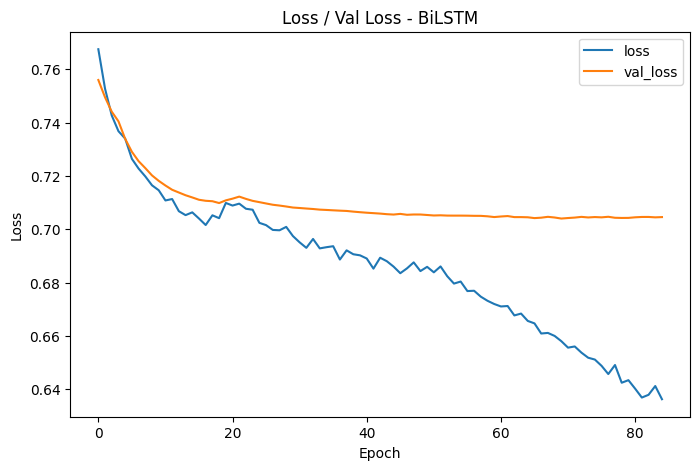

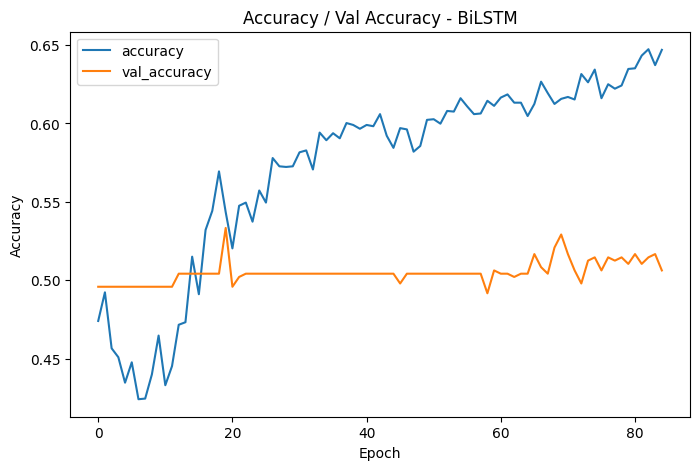

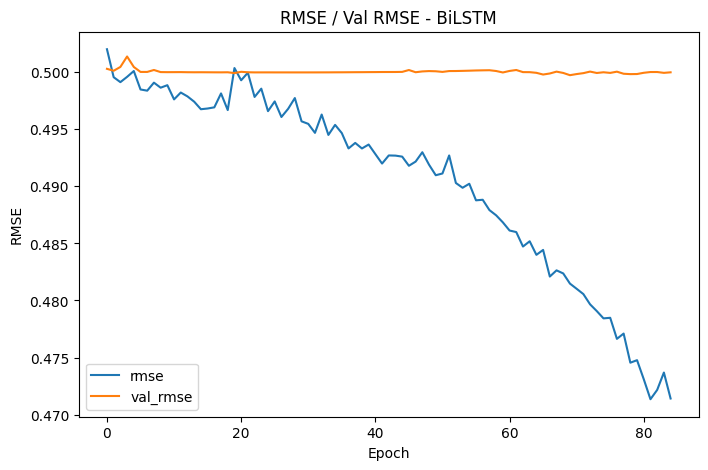

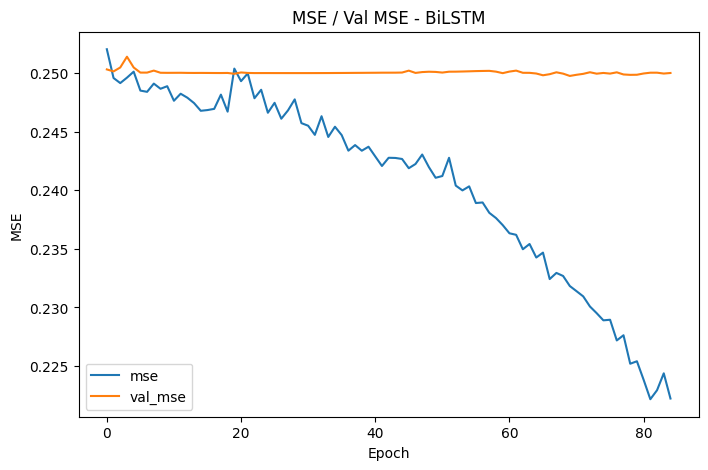

In [9]:
# B22DCCN476 - Đỗ Ngọc Lâm
hist = pd.DataFrame(history.history)

# 1️⃣ Loss / Val Loss
plt.figure()
plt.plot(hist['loss'], label='loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.title('Loss / Val Loss - BiLSTM')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# 2️⃣ Accuracy / Val Accuracy
plt.figure()
plt.plot(hist['accuracy'], label='accuracy')
plt.plot(hist['val_accuracy'], label='val_accuracy')
plt.title('Accuracy / Val Accuracy - BiLSTM')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

# 3️⃣ RMSE / Val RMSE
plt.figure()
plt.plot(hist['rmse'], label='rmse')
plt.plot(hist['val_rmse'], label='val_rmse')
plt.title('RMSE / Val RMSE - BiLSTM')
plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.legend(); plt.show()

# 4️⃣ MSE / Val MSE
plt.figure()
plt.plot(hist['mse'], label='mse')
plt.plot(hist['val_mse'], label='val_mse')
plt.title('MSE / Val MSE - BiLSTM')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()


***Cell 9 – Đánh giá LSTM & so sánh (biểu đồ cho baselines + model)***

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

Best threshold: 0.100 (Val F1=0.6630)

BiLSTM | VAL  Acc: 0.4958 | F1: 0.6630
BiLSTM | TEST Acc: 0.5353 | F1: 0.6973


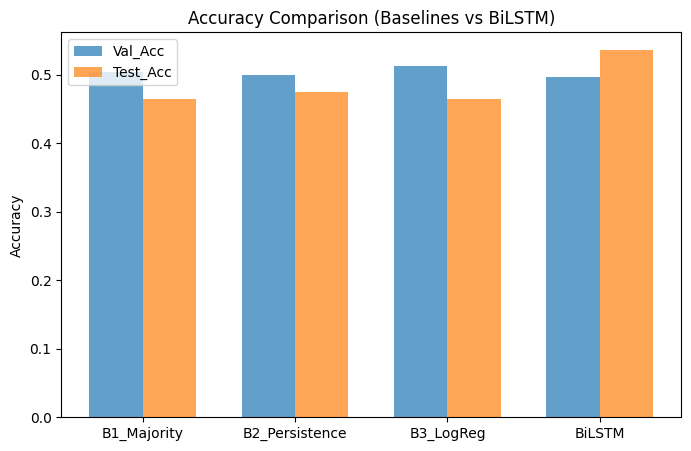

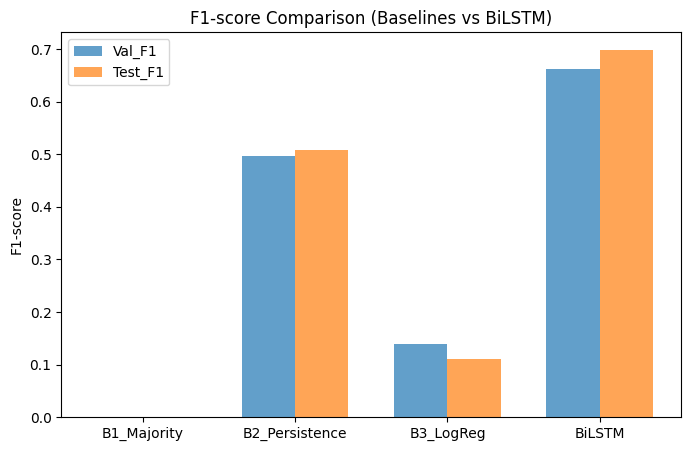

In [10]:
# B22DCCN476 - Đỗ Ngọc Lâm
from sklearn.metrics import accuracy_score, f1_score

# ======= Dự đoán xác suất =======
val_proba_nn  = model.predict(X_val_seq).ravel()
test_proba_nn = model.predict(X_test_seq).ravel()

# ======= Tối ưu ngưỡng theo F1 =======
def find_best_threshold(y_true, proba, metric='f1'):
    best_t, best_score = 0.5, -1
    for t in np.linspace(0.1, 0.9, 81):
        pred = (proba >= t).astype(int)
        score = f1_score(y_true, pred) if metric == 'f1' else accuracy_score(y_true, pred)
        if score > best_score:
            best_t, best_score = t, score
    return best_t, best_score

best_t, best_val_f1 = find_best_threshold(y_val_seq, val_proba_nn, 'f1')
print(f"\nBest threshold: {best_t:.3f} (Val F1={best_val_f1:.4f})")

# ======= Dự đoán với ngưỡng tối ưu =======
val_pred_nn  = (val_proba_nn  >= best_t).astype(int)
test_pred_nn = (test_proba_nn >= best_t).astype(int)

# ======= Đánh giá =======
acc_nn_val  = accuracy_score(y_val_seq,  val_pred_nn)
f1_nn_val   = f1_score(y_val_seq,       val_pred_nn)
acc_nn_test = accuracy_score(y_test_seq, test_pred_nn)
f1_nn_test  = f1_score(y_test_seq,      test_pred_nn)

print(f"\nBiLSTM | VAL  Acc: {acc_nn_val:.4f} | F1: {f1_nn_val:.4f}")
print(f"BiLSTM | TEST Acc: {acc_nn_test:.4f} | F1: {f1_nn_test:.4f}")

# ======= Biểu đồ so sánh với baseline =======
models = ['B1_Majority','B2_Persistence','B3_LogReg','BiLSTM']
val_accs  = [acc_b1_val, acc_b2_val, acc_b3a_val, acc_nn_val]
val_f1s   = [f1_b1_val,  f1_b2_val,  f1_b3a_val,  f1_nn_val]
test_accs = [acc_b1_test, acc_b2_test, acc_b3a_test, acc_nn_test]
test_f1s  = [f1_b1_test,  f1_b2_test,  f1_b3a_test,  f1_nn_test]

x = np.arange(len(models))
plt.figure()
plt.bar(x, val_accs, width=0.35, label='Val_Acc', alpha=0.7)
plt.bar(x+0.35, test_accs, width=0.35, label='Test_Acc', alpha=0.7)
plt.xticks(x+0.175, models)
plt.title('Accuracy Comparison (Baselines vs BiLSTM)')
plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure()
plt.bar(x, val_f1s, width=0.35, label='Val_F1', alpha=0.7)
plt.bar(x+0.35, test_f1s, width=0.35, label='Test_F1', alpha=0.7)
plt.xticks(x+0.175, models)
plt.title('F1-score Comparison (Baselines vs BiLSTM)')
plt.ylabel('F1-score'); plt.legend(); plt.show()


***Cell 10 – Chọn mô hình tốt nhất theo Validation & dự báo LÊN/XUỐNG theo ngày/tháng/năm***

In [11]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Chọn theo Val_Acc
compare = pd.DataFrame({
    'Model': ['B1_Majority','B2_Persistence','B3_LogReg','LSTM'],
    'Val_Acc': [acc_b1_val, acc_b2_val, acc_b3a_val, acc_nn_val],
    'Val_F1' : [f1_b1_val,  f1_b2_val,  f1_b3a_val,  f1_nn_val],
    'Test_Acc':[acc_b1_test, acc_b2_test, acc_b3a_test, acc_nn_test],
    'Test_F1' :[f1_b1_test,  f1_b2_test,  f1_b3a_test,  f1_nn_test],
})
compare = compare.sort_values('Val_Acc', ascending=False)
best_model_name = compare.iloc[0]['Model']
print("=== So sánh mô hình (theo Validation) ===")
print(compare.to_string(index=False))
print(f"\n>>> Mô hình được chọn: {best_model_name}")

# Lấy dự đoán TEST từ mô hình được chọn
def preds_by_name(name):
    if name == 'LSTM': return test_pred_nn
    if name == 'B3_LogReg': return y_test_b3
    if name == 'B2_Persistence': return y_test_b2
    return y_test_b1  # B1

test_pred_best = preds_by_name(best_model_name)

# Bảng dự báo cho tập TEST (đã window)
pred_df = pd.DataFrame({
    'Date': pd.to_datetime(dates_test_seq),
    'Actual_Up': y_test_seq,
    'Pred_Up': test_pred_best
}).sort_values('Date').reset_index(drop=True)
pred_df['DuBao'] = np.where(pred_df['Pred_Up']==1, 'LÊN', 'XUỐNG')

print("\nDự báo 10 dòng đầu của tập TEST:")
print(pred_df.head(10).to_string(index=False))

# Hàm lọc theo Y/M/D
def forecast_by_ymd(year=None, month=None, day=None):
    out = pred_df.copy()
    if year  is not None: out = out[out['Date'].dt.year == year]
    if month is not None: out = out[out['Date'].dt.month == month]
    if day   is not None: out = out[out['Date'].dt.day == day]
    return out[['Date','DuBao','Actual_Up','Pred_Up']].sort_values('Date')

# Ví dụ: dự báo cho năm phổ biến trong test
example_year = int(pred_df['Date'].dt.year.mode()[0])
print(f"\nVí dụ – Dự báo cho năm {example_year}:")
print(forecast_by_ymd(year=example_year).head(10).to_string(index=False))


=== So sánh mô hình (theo Validation) ===
         Model  Val_Acc   Val_F1  Test_Acc  Test_F1
     B3_LogReg 0.512500 0.139706  0.464730 0.110345
   B1_Majority 0.504167 0.000000  0.464730 0.000000
B2_Persistence 0.500000 0.495798  0.475104 0.508738
          LSTM 0.495833 0.662953  0.535270 0.697297

>>> Mô hình được chọn: B3_LogReg

Dự báo 10 dòng đầu của tập TEST:
      Date  Actual_Up  Pred_Up DuBao
2019-07-24          1        0 XUỐNG
2019-07-25          1        0 XUỐNG
2019-07-26          0        0 XUỐNG
2019-07-29          0        0 XUỐNG
2019-07-30          1        0 XUỐNG
2019-07-31          0        0 XUỐNG
2019-08-01          1        0 XUỐNG
2019-08-02          1        0 XUỐNG
2019-08-05          0        0 XUỐNG
2019-08-06          1        0 XUỐNG

Ví dụ – Dự báo cho năm 2020:
      Date DuBao  Actual_Up  Pred_Up
2020-01-02 XUỐNG          0        0
2020-01-03 XUỐNG          0        0
2020-01-06 XUỐNG          1        0
2020-01-07 XUỐNG          0        0
2020-01-

***Cell 11 – Báo cáo chi tiết & Confusion Matrix cho mô hình tốt nhất***

Hiệu năng TEST của 'B3_LogReg' | Acc: 0.4647 | F1: 0.1103

Classification report:
              precision    recall  f1-score   support

           0     0.4622    0.9286    0.6172       224
           1     0.5000    0.0620    0.1103       258

    accuracy                         0.4647       482
   macro avg     0.4811    0.4953    0.3638       482
weighted avg     0.4824    0.4647    0.3459       482



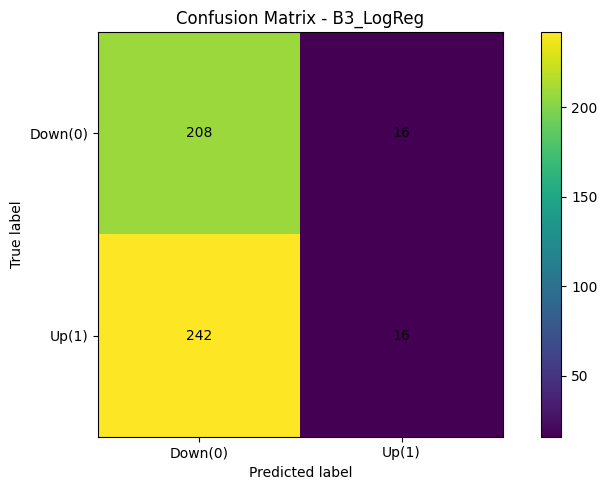

In [12]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Đánh giá lại trên TEST cho mô hình best
acc_best = accuracy_score(y_test_seq, test_pred_best)
f1_best  = f1_score(y_test_seq, test_pred_best)
print(f"Hiệu năng TEST của '{best_model_name}' | Acc: {acc_best:.4f} | F1: {f1_best:.4f}")
print("\nClassification report:")
print(classification_report(y_test_seq, test_pred_best, digits=4))

cm = confusion_matrix(y_test_seq, test_pred_best)
labels = ['Down(0)','Up(1)']

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout(); plt.show()


Biên độ tham chiếu (median abs return train): 0.9707%


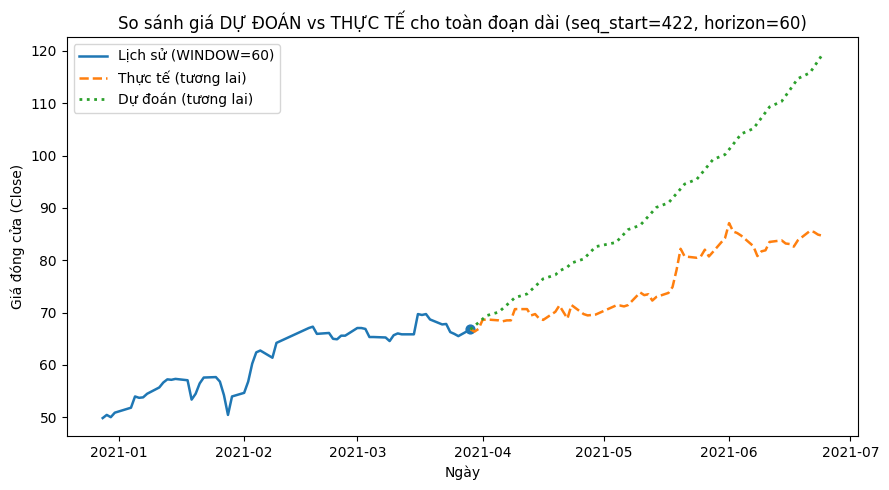

In [13]:
# B22DCCN476 - Đỗ Ngọc Lâm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Chuẩn bị lại vài mảng phục vụ vẽ (khớp split đã dùng) ===
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
test_start = n_train + n_val

close_test_all = df['Close'].iloc[test_start:].values
dates_test_all = pd.to_datetime(df['Date'].iloc[test_start:].values)

# Median absolute daily return trên TRAIN (làm biên độ dự đoán mỗi ngày)
close_train_all = df['Close'].iloc[:n_train].values
abs_ret_train = np.abs(close_train_all[1:] / close_train_all[:-1] - 1.0)
ref_abs_ret = float(np.median(abs_ret_train)) if len(abs_ret_train) > 0 else 0.01
print(f"Biên độ tham chiếu (median abs return train): {ref_abs_ret:.4%}")

def build_pred_path(seq_start: int, horizon: int):
    """
    Xây dựng đường giá dự đoán liên tiếp 'horizon' ngày, bắt đầu từ cửa sổ đầu tại seq_start.
    - seq_start: chỉ số sequence trong y_test_seq (0..len-1)
    - horizon: số ngày dự báo liên tiếp, thường chọn = WINDOW
    Yêu cầu: seq_start + horizon <= len(y_test_seq) và cũng phải không vượt dữ liệu test.
    """
    seq_start = int(seq_start)
    horizon   = int(horizon)

    total_seq = len(y_test_seq)
    if total_seq == 0:
        raise ValueError("Không có sequence ở tập test.")

    if seq_start < 0 or seq_start >= total_seq:
        raise ValueError(f"seq_start nằm ngoài phạm vi [0, {total_seq-1}].")

    # Số sequence tối đa có thể lấy liên tiếp
    max_horizon_by_seq = total_seq - seq_start
    horizon = min(horizon, max_horizon_by_seq, WINDOW)  # giới hạn an toàn = WINDOW

    # Điểm bắt đầu thời gian (cuối cửa sổ đầu tiên)
    start_price_idx = seq_start + WINDOW - 1
    # Dãy ngày tương lai (horizon ngày)
    future_idx_start = start_price_idx + 1
    future_idx_end   = future_idx_start + horizon  # exclusive

    if future_idx_end > len(close_test_all):
        # Nếu thiếu dữ liệu giá test, co ngắn horizon lại
        horizon = max(1, len(close_test_all) - future_idx_start)
        future_idx_end = future_idx_start + horizon

    # --- Real future series ---
    price0 = close_test_all[start_price_idx]
    real_future_prices = close_test_all[future_idx_start:future_idx_end]
    future_dates = dates_test_all[future_idx_start:future_idx_end]

    # --- Predicted signs for each day ---
    # test_pred_nn có 1 nhãn / sequence (mỗi sequence lệch 1 ngày),
    # nên  horizon bước tới tương ứng với các nhãn [seq_start .. seq_start + horizon - 1]
    signs = (test_pred_nn[seq_start:seq_start + horizon] * 2 - 1).astype(int)  # 1 -> +1, 0 -> -1

    # --- Reconstruct predicted path (giá dự đoán) ---
    pred_prices = np.empty(horizon, dtype=float)
    prev = price0
    for t in range(horizon):
        step = ref_abs_ret  # có thể thay bằng biên độ nội bộ tùy biến nếu muốn
        prev = prev * (1.0 + signs[t] * step)
        pred_prices[t] = prev

    # Lấy thêm đoạn lịch sử trước cửa sổ để bối cảnh (optional)
    hist_idx_start = max(0, start_price_idx - WINDOW + 1)
    hist_idx_end   = start_price_idx + 1  # inclusive end for plotting last context point
    hist_prices = close_test_all[hist_idx_start:hist_idx_end]
    hist_dates  = dates_test_all[hist_idx_start:hist_idx_end]

    return {
        'hist_dates': hist_dates,
        'hist_prices': hist_prices,
        'future_dates': future_dates,
        'real_future_prices': real_future_prices,
        'pred_future_prices': pred_prices,
        'price0_date': dates_test_all[start_price_idx],
        'price0': price0,
        'seq_start': seq_start,
        'horizon': horizon
    }

def plot_future_block(seq_start=None, horizon=None, show_history=True):
    """
    Vẽ so sánh giá thực vs dự đoán cho 'horizon' ngày kế tiếp, bắt đầu từ 'seq_start'.
    - Nếu seq_start=None: dùng seq cuối cùng có đủ horizon.
    - horizon mặc định = WINDOW (và sẽ tự co nếu không đủ).
    """
    total_seq = len(y_test_seq)
    if total_seq == 0:
        print("Không có sequence ở tập test để vẽ.")
        return

    if horizon is None:
        horizon = WINDOW

    if seq_start is None:
        # chọn seq_start muộn nhất sao cho lấy đủ 'horizon'
        seq_start = max(0, total_seq - horizon)

    pack = build_pred_path(seq_start, horizon)
    hist_dates, hist_prices = pack['hist_dates'], pack['hist_prices']
    future_dates = pack['future_dates']
    real_future_prices = pack['real_future_prices']
    pred_future_prices = pack['pred_future_prices']
    price0_date, price0 = pack['price0_date'], pack['price0']

    plt.figure(figsize=(9, 5))

    # Lịch sử trong window trước điểm bắt đầu
    if show_history:
        plt.plot(hist_dates, hist_prices, label=f'Lịch sử (WINDOW={WINDOW})', linewidth=1.8)
        # vẽ marker ở điểm bắt đầu
        plt.scatter([price0_date], [price0], s=40)

    # Nối từ điểm bắt đầu sang chuỗi tương lai thật
    plt.plot([price0_date, *future_dates], [price0, *real_future_prices],
             linestyle='--', label='Thực tế (tương lai)', linewidth=1.8)

    # Nối từ điểm bắt đầu sang chuỗi tương lai dự đoán
    plt.plot([price0_date, *future_dates], [price0, *pred_future_prices],
             linestyle=':', label='Dự đoán (tương lai)', linewidth=2.0)

    plt.title(f"So sánh giá DỰ ĐOÁN vs THỰC TẾ cho toàn đoạn dài (seq_start={pack['seq_start']}, horizon={pack['horizon']})")
    plt.xlabel("Ngày"); plt.ylabel("Giá đóng cửa (Close)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Ví dụ sử dụng ===
# 1) Vẽ đoạn dài đúng bằng WINDOW ngày, từ sequence cuối cùng có đủ dữ liệu:
plot_future_block(seq_start=None, horizon=WINDOW, show_history=True)

# 2) Vẽ một đoạn bất kỳ (ví dụ bắt đầu tại seq_start = 10) trong test:
# plot_future_block(seq_start=10, horizon=WINDOW, show_history=True)


In [14]:
# Cell 1 — Import & cấu hình
#B22DCCN476 - Đỗ Ngọc Lâm
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True)


In [15]:
# Cell 2 — Hàm load & tiền xử lý dữ liệu (kế thừa code của bạn, linh hoạt cột hoa/thường)
#B22DCCN476 - Đỗ Ngọc Lâm
def load_csv_ticker(path_csv):
    df = pd.read_csv(path_csv)
    # Chuẩn hoá tên cột về lowercase
    df.columns = [c.strip().lower() for c in df.columns]
    # Chuẩn hoá tên một số cột phổ biến
    rename_map = {
        'tradingdate':'date', 'date':'date',
        'close':'close','open':'open','high':'high','low':'low','volume':'volume',
        'symbol':'symbol','time':'time','value':'value'
    }
    # chỉ giữ lại các cột có trong df
    rename_map = {k:v for k,v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)
    if 'date' in df.columns:
        # thử parse dd/mm/yyyy và yyyy-mm-dd
        def try_parse(x):
            for fmt in ("%d/%m/%Y","%Y-%m-%d","%d-%m-%Y","%m/%d/%Y"):
                try:
                    return datetime.strptime(str(x), fmt)
                except:
                    pass
            return pd.NaT
        df['date'] = df['date'].apply(try_parse)
    # Sắp xếp theo ngày tăng dần nếu có cột date
    if 'date' in df.columns:
        df = df.sort_values('date').reset_index(drop=True)
    return df

def build_features(df_raw):
    df = df_raw.copy()

    required = ['close','high','low','volume']
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Thiếu cột bắt buộc: {col}")

    # Thay thế volume <= 0
    if (df['volume'] <= 0).any():
        min_pos = df.loc[df['volume']>0, 'volume'].min()
        df.loc[df['volume']<=0, 'volume'] = max(1.0, min_pos*0.01)

    # Giá phải > 0
    for pc in ['close','high','low']:
        if (df[pc] <= 0).any():
            raise ValueError(f"Giá {pc} không hợp lệ (<=0)")

    # Tính feature
    df['daily_return'] = df['close'].pct_change().replace([np.inf,-np.inf], np.nan)
    df['high_low_range'] = ((df['high']-df['low'])/df['close']).replace([np.inf,-np.inf], np.nan)
    if 'open' in df.columns:
        df['close_to_open'] = ((df['close']-df['open'])/df['open']).replace([np.inf,-np.inf], np.nan)

    df['ma5'] = df['close'].rolling(5).mean()
    df['ma20'] = df['close'].rolling(20).mean()
    df['ma_ratio'] = np.where(df['ma20'].notnull() & (df['ma20']!=0),
                              df['ma5']/df['ma20'], np.nan)

    df['volatility_5d'] = df['daily_return'].rolling(5).std().replace([np.inf,-np.inf], np.nan)
    df['volume_ma5'] = df['volume'].rolling(5).mean()
    df['volume_ratio'] = np.where(df['volume_ma5'].notnull() & (df['volume_ma5']!=0),
                                  df['volume']/df['volume_ma5'], np.nan)

    # Fill NaN
    df = df.ffill().fillna(0)

    # Tập features
    features = ['close','volume','high','low']
    if 'open' in df.columns:
        features = ['close','open','volume','high','low']

    add_feats = ['daily_return','high_low_range','ma_ratio','volatility_5d','volume_ratio']
    if 'open' in df.columns: add_feats.append('close_to_open')

    extended_features = features + [f for f in add_feats if f in df.columns]
    return df, extended_features


C:\Users\Admin\AppData\Local\Temp\ipykernel_17368\1248509641.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '39.9' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['volume']<=0, 'volume'] = max(1.0, min_pos*0.01)


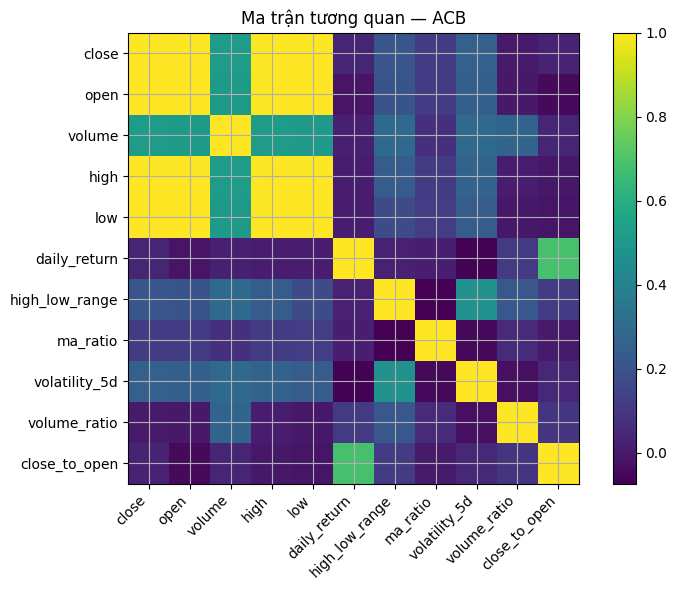

In [16]:
# Cell 3 — Tạo ma trận tương quan trước khi huấn luyện
#B22DCCN476 - Đỗ Ngọc Lâm
# Chỉnh đường dẫn/ticker theo thư mục của bạn
base_dir = r"C:/Users/Admin/Desktop/PTIT/Y4_T1/IntSys/ktra3/Data/Stock_Prices_VN-30_Index-Vietnam_10years_to_2023"
ticker = "ACB"  # đổi sang mã khác nếu muốn
csv_path = os.path.join(base_dir, f"{ticker}.csv")

df_raw = load_csv_ticker(csv_path)
df_feat, feat_cols = build_features(df_raw)

corr = df_feat[feat_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))
cax = ax.imshow(corr.values, interpolation='nearest')
ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(feat_cols, rotation=45, ha='right')
ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(feat_cols)
fig.colorbar(cax)
ax.set_title(f"Ma trận tương quan — {ticker}")
plt.tight_layout()
plt.show()


In [17]:
# Cell 4 — Tạo chuỗi cho LSTM + chuẩn hoá + chia train/test (giữ giống cách của bạn)
#B22DCCN476 - Đỗ Ngọc Lâm
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_feat[feat_cols].values)

def create_dataset(data, window_size=30):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # cột 0 là close (đầu tiên trong feat_cols)
    return np.array(X), np.array(y)

window_size = 30
X, y = create_dataset(scaled, window_size)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Shapes: (2140, 30, 11) (536, 30, 11) (2140,) (536,)


In [18]:
# Cell 5 — Callback để log Direction Accuracy, MSE, RMSE mỗi epoch (train/val)
#B22DCCN476 - Đỗ Ngọc Lâm
class MetricsLogger(Callback):
    def __init__(self, X_tr, y_tr, X_va, y_va, scaler, feat_len):
        super().__init__()
        self.Xtr, self.ytr = X_tr, y_tr
        self.Xva, self.yva = X_va, y_va
        self.scaler = scaler
        self.feat_len = feat_len
        self.history_extra = {
            "acc": [], "val_acc": [],
            "rmse": [], "val_rmse": [],
            "mse": [], "val_mse": []
        }

    @staticmethod
    def _inverse_close(scaled_close, scaler, feat_len):
        tmp = np.zeros((len(scaled_close), feat_len))
        tmp[:,0] = scaled_close.reshape(-1)
        return scaler.inverse_transform(tmp)[:,0]

    def on_epoch_end(self, epoch, logs=None):
        # train
        pred_tr = self.model.predict(self.Xtr, verbose=0).reshape(-1)
        pred_va = self.model.predict(self.Xva, verbose=0).reshape(-1)

        ytr_inv = self._inverse_close(self.ytr, self.scaler, self.feat_len)
        yva_inv = self._inverse_close(self.yva, self.scaler, self.feat_len)
        ptr_inv = self._inverse_close(pred_tr, self.scaler, self.feat_len)
        pva_inv = self._inverse_close(pred_va, self.scaler, self.feat_len)

        # Direction accuracy: so sánh hướng tăng/giảm so với giá thực ở bước liền trước
        def dir_acc(true_inv, pred_inv):
            if len(true_inv) < 2: return 0.0
            actual_dir = (true_inv[1:] > true_inv[:-1]).astype(int)
            pred_dir = (pred_inv[1:] > true_inv[:-1]).astype(int)
            return np.mean(actual_dir == pred_dir)

        tr_acc = dir_acc(ytr_inv, ptr_inv)
        va_acc = dir_acc(yva_inv, pva_inv)

        tr_mse = mean_squared_error(ytr_inv, ptr_inv)
        va_mse = mean_squared_error(yva_inv, pva_inv)
        tr_rmse, va_rmse = math.sqrt(tr_mse), math.sqrt(va_mse)

        self.history_extra["acc"].append(tr_acc)
        self.history_extra["val_acc"].append(va_acc)
        self.history_extra["mse"].append(tr_mse)
        self.history_extra["val_mse"].append(va_mse)
        self.history_extra["rmse"].append(tr_rmse)
        self.history_extra["val_rmse"].append(va_rmse)


In [29]:
# Cell 6 — Xây LSTM >= 5 layer + hiển thị RMSE/MSE trong lúc train
#B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras.layers import BatchNormalization
def build_deep_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(96, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(48, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])
    # Hiển thị MSE/RMSE của Keras (trên dữ liệu đã scale)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.MeanSquaredError(name='mse'),
                 tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

# (OPTIONAL) — Cập nhật MetricsLogger để in RMSE/MSE sau khi inverse về giá gốc
#B22DCCN476 - Đỗ Ngọc Lâm
class MetricsLogger(MetricsLogger):  # kế thừa lại class bạn đã định nghĩa ở Cell 5
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        # In thêm chỉ số trên thang đo gốc (inverse)
        tr_rmse = self.history_extra["rmse"][-1]
        va_rmse = self.history_extra["val_rmse"][-1]
        tr_mse  = self.history_extra["mse"][-1]
        va_mse  = self.history_extra["val_mse"][-1]
        tr_acc  = self.history_extra["acc"][-1]
        va_acc  = self.history_extra["val_acc"][-1]
        print(f"[Epoch {epoch+1}] Inverse-scale -> RMSE: {tr_rmse:.4f} | Val_RMSE: {va_rmse:.4f} | "
              f"MSE: {tr_mse:.6f} | Val_MSE: {va_mse:.6f} | ACC: {tr_acc:.3f} | Val_ACC: {va_acc:.3f}")

deep_model = build_deep_lstm((window_size, X.shape[2]))

early = EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)

logger = MetricsLogger(X_train, y_train, X_test, y_test, scaler, len(feat_cols))

hist = deep_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, batch_size=32, verbose=1,   # verbose=1 để Keras cũng in mse/rmse đã scale
    callbacks=[logger, early, reduce_lr]
)


Epoch 1/200


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0933 - mse: 0.0933 - rmse: 0.2918[Epoch 1] Inverse-scale -> RMSE: 7441.4268 | Val_RMSE: 7943.0833 | MSE: 55374832.213619 | Val_MSE: 63092571.656506 | ACC: 0.441 | Val_ACC: 0.561
[Epoch 1] Inverse-scale -> RMSE: 7441.4268 | Val_RMSE: 7943.0833 | MSE: 55374832.213619 | Val_MSE: 63092571.656506 | ACC: 0.441 | Val_ACC: 0.561
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0422 - mse: 0.0422 - rmse: 0.2055 - val_loss: 0.0468 - val_mse: 0.0468 - val_rmse: 0.2164 - learning_rate: 0.0010
Epoch 2/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0122 - mse: 0.0122 - rmse: 0.1095[Epoch 2] Inverse-scale -> RMSE: 5979.2138 | Val_RMSE: 5540.6133 | MSE: 35750997.853810 | Val_MSE: 30698396.217707 | ACC: 0.430 | Val_ACC: 0.553
[Epoch 2] Inverse-scale -> RMSE: 5979.2138 | Val_RMSE: 5540.6133 | MSE: 35750997.853810 | Val_MSE: 30698396.217707 | ACC: 0.430 | Val_ACC: 0.553
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0097 - mse: 0.0097 - rmse: 0

In [30]:
# Cell 7 — Dự đoán & đánh giá LSTM (RMSE, R2, Direction Accuracy) + dự báo ngày tới
#B22DCCN476 - Đỗ Ngọc Lâm
def inverse_close(arr_scaled):
    tmp = np.zeros((len(arr_scaled), len(feat_cols)))
    tmp[:,0] = arr_scaled.reshape(-1)
    return scaler.inverse_transform(tmp)[:,0]

pred_test_scaled = deep_model.predict(X_test).reshape(-1)
y_test_inv = inverse_close(y_test)
y_pred_inv = inverse_close(pred_test_scaled)

rmse_lstm = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2_lstm = r2_score(y_test_inv, y_pred_inv)

# Direction accuracy theo test
actual_dir = (y_test_inv[1:] > y_test_inv[:-1]).astype(int)
pred_dir = (y_pred_inv[1:] > y_test_inv[:-1]).astype(int)
acc_lstm = np.mean(actual_dir == pred_dir)

# Dự báo ngày kế tiếp
last_seq = scaled[-window_size:].reshape(1, window_size, len(feat_cols))
next_scaled = deep_model.predict(last_seq)[0,0]
next_full = np.zeros((1, len(feat_cols))); next_full[0,0] = next_scaled
next_price = scaler.inverse_transform(next_full)[0,0]
cur_price = df_feat['close'].iloc[-1]
change_pct = (next_price - cur_price) / cur_price * 100

print(f"LSTM — RMSE: {rmse_lstm:.4f} | R2: {r2_lstm:.4f} | Direction Acc: {acc_lstm:.4f}")
print(f"Dự báo tiếp theo cho {ticker}: {next_price:.2f} ({change_pct:+.2f}%)")

# ngày/tháng/năm cho dự báo
last_date = df_feat['date'].iloc[-1] if 'date' in df_feat.columns else None
if last_date is not None:
    next_date = last_date + pd.Timedelta(days=1)
    print("Ngày dự báo:", next_date.strftime("%d/%m/%Y"))
    print("Xu hướng:", "UP" if change_pct>0 else "DOWN")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
LSTM — RMSE: 1652.6000 | R2: 0.8994 | Direction Acc: 0.5570
Dự báo tiếp theo cho ACB: 22520.61 (+2.13%)
Ngày dự báo: 01/07/2023
Xu hướng: UP


In [31]:
# Cell 8 — Baseline 1: Naive Persistence (giá ngày mai = giá hôm nay)
#B22DCCN476 - Đỗ Ngọc Lâm
# Lấy "close" gốc tương ứng tập test để baseline so sánh công bằng
# y_test_inv đã là close thật cho các vị trí dự đoán (t+window)
# Dự đoán naive = close ở thời điểm trước đó của chuỗi test (dịch 1)
naive_pred = np.r_[y_test_inv[0], y_test_inv[:-1]]

rmse_naive = math.sqrt(mean_squared_error(y_test_inv, naive_pred))
r2_naive = r2_score(y_test_inv, naive_pred)
acc_naive = np.mean((y_test_inv[1:] > y_test_inv[:-1]) == (naive_pred[1:] > y_test_inv[:-1]))

# Tạo "history" phẳng để tiện vẽ đường (baseline không có epoch)
epochs_plot = len(hist.history['loss'])
hist_naive = {
    "loss": [rmse_naive**2]*epochs_plot,
    "val_loss": [rmse_naive**2]*epochs_plot,
    "mse": [rmse_naive**2]*epochs_plot,
    "val_mse": [rmse_naive**2]*epochs_plot,
    "rmse": [rmse_naive]*epochs_plot,
    "val_rmse": [rmse_naive]*epochs_plot,
    "acc": [acc_naive]*epochs_plot,
    "val_acc": [acc_naive]*epochs_plot
}
print(f"Naive — RMSE: {rmse_naive:.4f} | R2: {r2_naive:.4f} | Direction Acc: {acc_naive:.4f}")


Naive — RMSE: 723.4705 | R2: 0.9807 | Direction Acc: 0.5477


In [32]:
# Cell 9 — Baseline 2: Moving Average (MA5) cho close
#B22DCCN476 - Đỗ Ngọc Lâm
# Tính MA5 trên chuỗi close gốc tương ứng với y_test_inv
ma5 = pd.Series(y_test_inv).rolling(5).mean().bfill().values
rmse_ma = math.sqrt(mean_squared_error(y_test_inv, ma5))
r2_ma = r2_score(y_test_inv, ma5)
acc_ma = np.mean((y_test_inv[1:] > y_test_inv[:-1]) == (ma5[1:] > y_test_inv[:-1]))

hist_ma = {
    "loss": [rmse_ma**2]*epochs_plot,
    "val_loss": [rmse_ma**2]*epochs_plot,
    "mse": [rmse_ma**2]*epochs_plot,
    "val_mse": [rmse_ma**2]*epochs_plot,
    "rmse": [rmse_ma]*epochs_plot,
    "val_rmse": [rmse_ma]*epochs_plot,
    "acc": [acc_ma]*epochs_plot,
    "val_acc": [acc_ma]*epochs_plot
}
print(f"MA5 — RMSE: {rmse_ma:.4f} | R2: {r2_ma:.4f} | Direction Acc: {acc_ma:.4f}")


MA5 — RMSE: 764.1550 | R2: 0.9785 | Direction Acc: 0.5963


In [33]:
# Cell 10 — Baseline 3: SGDRegressor theo từng epoch (sử dụng cửa sổ phẳng)
#B22DCCN476 - Đỗ Ngọc Lâm
# Chuyển X (window, features) -> vector phẳng cho mô hình tuyến tính
X_flat = X.reshape((X.shape[0], -1))
X_train_flat, X_test_flat = X_flat[:split], X_flat[split:]

sgd = SGDRegressor(alpha=1e-4, penalty='l2', max_iter=1, learning_rate='invscaling', eta0=0.01, random_state=42)
# partial_fit cần target là số thực
unique_epochs = epochs_plot
mse_tr_hist, mse_va_hist, rmse_tr_hist, rmse_va_hist, acc_tr_hist, acc_va_hist = [], [], [], [], [], []

for ep in range(unique_epochs):
    sgd.partial_fit(X_train_flat, y_train)  # mỗi vòng = 1 epoch
    pred_tr = sgd.predict(X_train_flat)
    pred_va = sgd.predict(X_test_flat)

    # đảo ngược về giá close thật
    def inv(arr):
        tmp = np.zeros((len(arr), len(feat_cols))); tmp[:,0] = arr
        return scaler.inverse_transform(tmp)[:,0]
    ptr, pva = inv(pred_tr), inv(pred_va)
    ytr_inv_s, yva_inv_s = inv(y_train), inverse_close(y_test)

    mse_tr = mean_squared_error(ytr_inv_s, ptr)
    mse_va = mean_squared_error(yva_inv_s, pva)
    rmse_tr, rmse_va = math.sqrt(mse_tr), math.sqrt(mse_va)

    def dacc(y_true_inv, y_pred_inv):
        if len(y_true_inv)<2: return 0.0
        return np.mean((y_true_inv[1:] > y_true_inv[:-1]) == (y_pred_inv[1:] > y_true_inv[:-1]))

    acc_tr_hist.append(dacc(ytr_inv_s, ptr))
    acc_va_hist.append(dacc(yva_inv_s, pva))
    mse_tr_hist.append(mse_tr); mse_va_hist.append(mse_va)
    rmse_tr_hist.append(rmse_tr); rmse_va_hist.append(rmse_va)

hist_sgd = {
    "loss": mse_tr_hist,
    "val_loss": mse_va_hist,
    "mse": mse_tr_hist,
    "val_mse": mse_va_hist,
    "rmse": rmse_tr_hist,
    "val_rmse": rmse_va_hist,
    "acc": acc_tr_hist,
    "val_acc": acc_va_hist
}

print(f"SGDRegressor — RMSE(val): {rmse_va_hist[-1]:.4f} | MSE(val): {mse_va_hist[-1]:.4f} | Acc(val): {acc_va_hist[-1]:.4f}")


SGDRegressor — RMSE(val): 1001.4579 | MSE(val): 1002917.8261 | Acc(val): 0.5196


In [34]:
# Cell 11 — Gom lịch sử LSTM (từ Keras + callback) để vẽ đồng nhất
#B22DCCN476 - Đỗ Ngọc Lâm
hist_lstm = {
    "loss": hist.history['loss'],
    "val_loss": hist.history['val_loss'],
    "mse": logger.history_extra['mse'],
    "val_mse": logger.history_extra['val_mse'],
    "rmse": logger.history_extra['rmse'],
    "val_rmse": logger.history_extra['val_rmse'],
    "acc": logger.history_extra['acc'],
    "val_acc": logger.history_extra['val_acc']
}

models_histories = {
    "LSTM(5-layer+)": hist_lstm,
    "Naive": hist_naive,
    "MA5": hist_ma,
    "SGDReg": hist_sgd
}


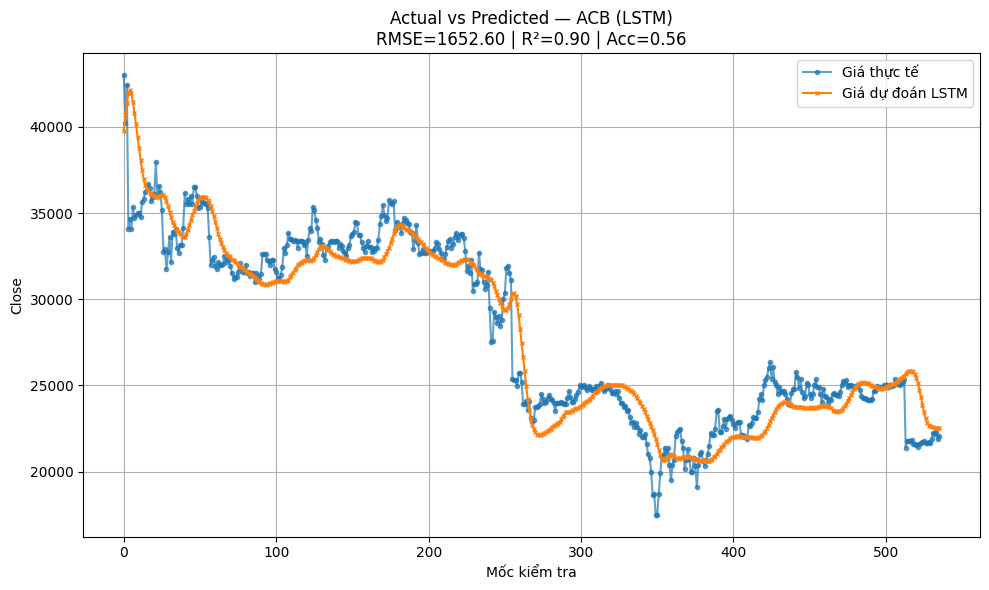

In [35]:
# Cell 12 — Biểu đồ 1: Actual vs Predicted (Test) cho LSTM
#B22DCCN476 - Đỗ Ngọc Lâm
plt.figure()
plt.plot(y_test_inv, label="Giá thực tế", marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred_inv, label="Giá dự đoán LSTM", marker='x', markersize=3)
plt.title(f"Actual vs Predicted — {ticker} (LSTM)\nRMSE={rmse_lstm:.2f} | R²={r2_lstm:.2f} | Acc={acc_lstm:.2f}")
plt.xlabel("Mốc kiểm tra"); plt.ylabel("Close")
plt.legend(); plt.tight_layout(); plt.show()


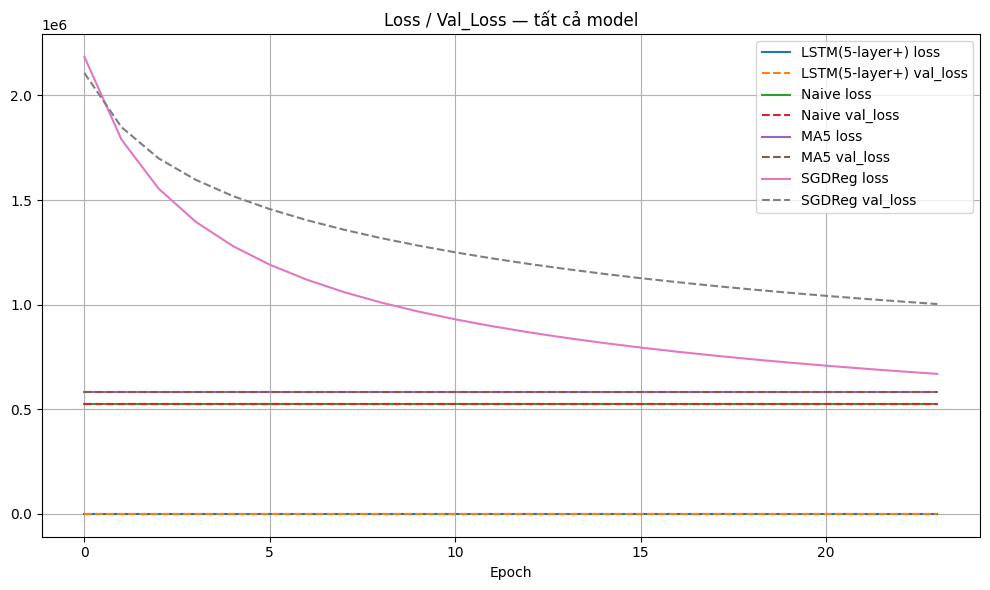

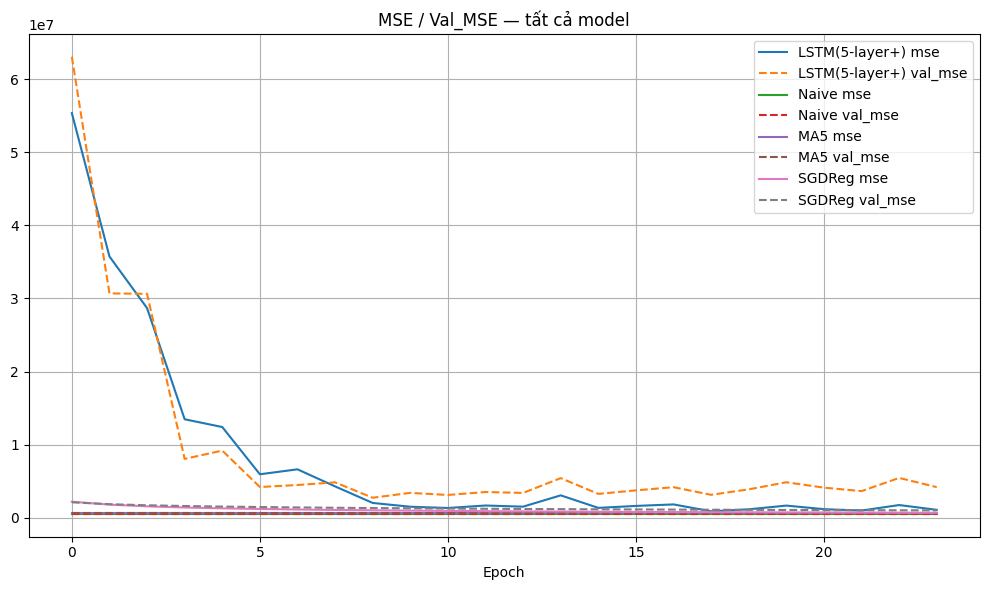

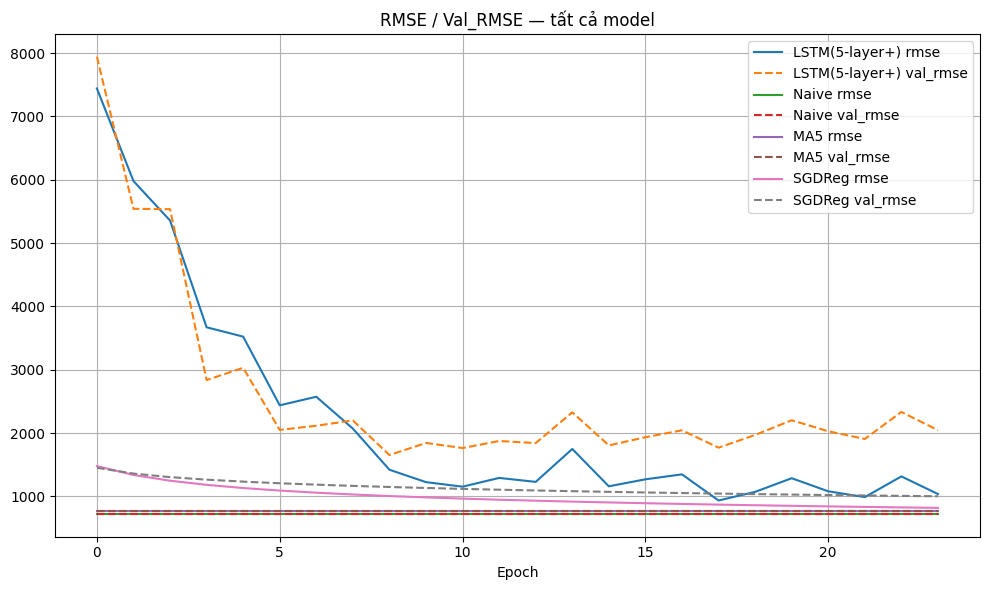

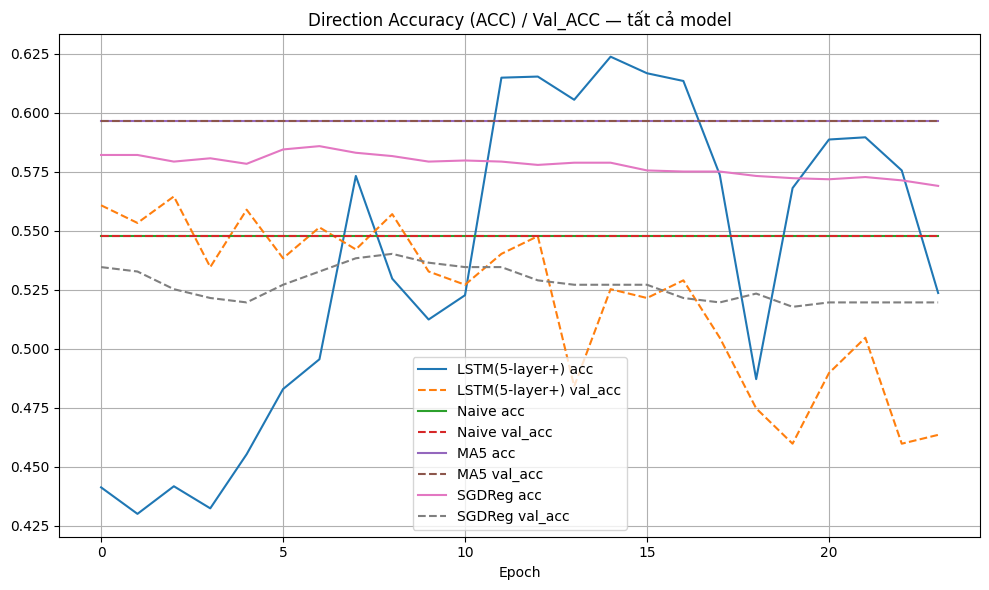

In [36]:
# Cell 13 — Biểu đồ 2~6: loss/val_loss, train/val (mse, rmse, acc) cho TẤT CẢ models
#B22DCCN476 - Đỗ Ngọc Lâm
def plot_metric_all(models_hist, key, title):
    plt.figure()
    for name, hh in models_hist.items():
        plt.plot(hh[key], label=f"{name} {key}")
        vkey = "val_"+key if not key.startswith("val_") else key
        if vkey in hh:
            plt.plot(hh[vkey], linestyle='--', label=f"{name} val_{key if not key.startswith('val_') else key[4:]}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2: loss/val_loss
plot_metric_all(models_histories, "loss", "Loss / Val_Loss — tất cả model")

# 3: mse/val_mse
plot_metric_all(models_histories, "mse", "MSE / Val_MSE — tất cả model")

# 4: rmse/val_rmse
plot_metric_all(models_histories, "rmse", "RMSE / Val_RMSE — tất cả model")

# 5: acc/val_acc (direction accuracy)
plot_metric_all(models_histories, "acc", "Direction Accuracy (ACC) / Val_ACC — tất cả model")


In [37]:
# Cell 14 — Chọn mô hình tốt nhất & in kết luận dự báo (Cổ phiếu, ngày/tháng/năm, lên/xuống)
#B22DCCN476 - Đỗ Ngọc Lâm
# Tiêu chí: RMSE (val) cuối cùng thấp nhất
def last_val_rmse(h): 
    if 'val_rmse' in h and len(h['val_rmse'])>0: 
        return h['val_rmse'][-1]
    # fallback
    if 'rmse' in h and len(h['rmse'])>0:
        return h['rmse'][-1]
    return float('inf')

best_name = min(models_histories.keys(), key=lambda k: last_val_rmse(models_histories[k]))
best_rmse = last_val_rmse(models_histories[best_name])

print(f"Mô hình tốt nhất: {best_name} (Val RMSE ~ {best_rmse:.4f})")

# Lấy dự báo ngày tới từ mô hình tốt nhất
if best_name.startswith("LSTM"):
    best_price = next_price
    best_change = change_pct
else:
    # Với baseline: dự báo bằng phương pháp tương ứng
    cur_close = df_feat['close'].iloc[-1]
    if best_name == "Naive":
        best_price = cur_close  # ngày mai = hôm nay
    elif best_name == "MA5":
        best_price = df_feat['close'].rolling(5).mean().iloc[-1]
    elif best_name == "SGDReg":
        # dùng mô hình SGD đã huấn luyện sau cùng để dự báo next step
        next_flat = scaled[-window_size:].reshape(1, -1)
        pred_scaled = sgd.predict(next_flat)[0]
        tmp = np.zeros((1, len(feat_cols))); tmp[0,0] = pred_scaled
        best_price = float(scaler.inverse_transform(tmp)[0,0])
    best_change = (best_price - cur_price)/cur_price*100

# Thông tin ngày
last_date = df_feat['date'].iloc[-1] if 'date' in df_feat.columns else pd.Timestamp.today()
next_date = last_date + pd.Timedelta(days=1)

print(f"Dự báo cho cổ phiếu {ticker} — Ngày {next_date.strftime('%d/%m/%Y')}")
print(f"Giá dự báo: {best_price:.2f} VND — Thay đổi: {best_change:+.2f}% — Xu hướng: {'UP' if best_change>0 else 'DOWN'}")


Mô hình tốt nhất: Naive (Val RMSE ~ 723.4705)
Dự báo cho cổ phiếu ACB — Ngày 01/07/2023
Giá dự báo: 22050.00 VND — Thay đổi: +0.00% — Xu hướng: DOWN


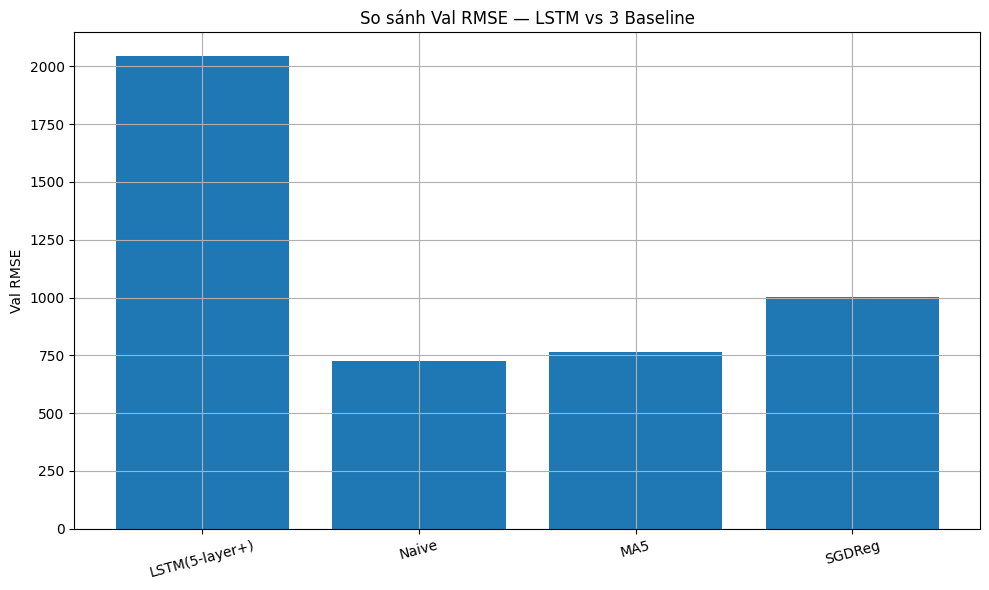

In [38]:
# Cell 15 — Biểu đồ bổ sung (thứ 6): So sánh RMSE cuối cùng của 4 mô hình (cột)
#B22DCCN476 - Đỗ Ngọc Lâm
names = []
vals = []
for name, h in models_histories.items():
    names.append(name)
    vals.append(last_val_rmse(h))

plt.figure()
plt.bar(names, vals)
plt.title("So sánh Val RMSE — LSTM vs 3 Baseline")
plt.ylabel("Val RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
